In [1]:
# 데이터 처리를 위한 pandas와 numpy를 불러옵니다.
import pandas as pd
import numpy as np

# 그래프를 그리기 위한 matplotlib와 seaborn을 불러옵니다.
import matplotlib.pyplot as plt
import seaborn as sns

# 폴더 생성을 위해 os를 불러옵니다.
import os

# 윈도우 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 결과 저장 폴더 생성
os.makedirs("../images", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)


In [2]:
# 상습 발생지 원본 파일
hotspot_file = "../data/대구광역시 북구_불법주정차 상습 발생지 현장 정보_20211123.csv"

# 이미 팀원이 전처리한 민원, CCTV, 2025 단속 데이터
complaint_file = "../data/processed/lee_complaint_2018_2021.csv"
cctv_file = "../data/processed/lee_cctv_location.csv"
violation_2025_file = "../data/processed/violation_2025.csv"

# 파일을 불러옵니다.
hotspot = pd.read_csv(hotspot_file, encoding="utf-8-sig")
complaint = pd.read_csv(complaint_file, encoding="utf-8-sig")
cctv = pd.read_csv(cctv_file, encoding="utf-8-sig")
violation_2025 = pd.read_csv(violation_2025_file, encoding="utf-8-sig")

# 데이터 크기 확인
print("상습 발생지:", hotspot.shape)
print("민원 전처리 데이터:", complaint.shape)
print("CCTV 전처리 데이터:", cctv.shape)
print("2025 단속 데이터:", violation_2025.shape)


상습 발생지: (142, 11)
민원 전처리 데이터: (14672, 7)
CCTV 전처리 데이터: (719, 9)
2025 단속 데이터: (12241, 8)


In [3]:
# 원본 상습 발생지 데이터의 좌표 범위를 확인합니다.
print("원본 경도 범위:", hotspot["경도"].min(), "~", hotspot["경도"].max())
print("원본 위도 범위:", hotspot["위도"].min(), "~", hotspot["위도"].max())

# 대구의 위도는 약 35, 경도는 약 128이므로 컬럼명을 서로 바꿉니다.
hotspot = hotspot.rename(columns={
    "경도": "위도",
    "위도": "경도"
})

# 주소에서 동 이름을 추출합니다.
dong = hotspot["주소"].str.extract(r"([가-힣]+?)\d*(동)(?:\d가)?")
hotspot["동"] = dong[0] + dong[1]

# 같은 주소가 몇 번 반복되는지 확인합니다.
print("원본 행 수:", len(hotspot))
print("서로 다른 주소 수:", hotspot["주소"].nunique())
print("중복 주소 행 수:", hotspot.duplicated(subset=["주소"]).sum())


원본 경도 범위: 35.879213 ~ 35.954528
원본 위도 범위: 128.546818 ~ 128.623307
원본 행 수: 142
서로 다른 주소 수: 25
중복 주소 행 수: 117


In [4]:
# 같은 주소는 하나의 상습 발생지로 묶습니다.
# 민원 건수는 주소마다 반복되어 있으므로 첫 값을 사용하고,
# 여러 현장 좌표는 대표값으로 평균을 사용합니다.
hotspot_clean = (
    hotspot.groupby(["주소", "동"], as_index=False)
    .agg(
        민원발생누적건수=("민원발생누적건수", "first"),
        민원2018=("2018년 민원발생건수", "first"),
        민원2019=("2019년 민원발생건수", "first"),
        민원2020=("2020년 민원발생건수", "first"),
        민원2021=("2021년 민원발생건수", "first"),
        위도=("위도", "mean"),
        경도=("경도", "mean"),
        현장사진수=("현장정보", "count")
    )
)

# 짧은 주소를 추가합니다.
hotspot_clean["짧은주소"] = hotspot_clean["주소"].str.replace(
    "대구광역시 북구 ", "", regex=False
)

print("정리 후 상습 발생지 수:", len(hotspot_clean))
display(hotspot_clean.head())


정리 후 상습 발생지 수: 25


,주소,동,민원발생누적건수,민원2018,민원2019,민원2020,민원2021,위도,경도,현장사진수,짧은주소
0,대구광역시 북구 구암동 714,구암동,252,0,0,252,0,35.927725,128.555214,3,구암동 714
1,대구광역시 북구 구암동 716,구암동,268,0,0,268,0,35.930655,128.554187,5,구암동 716
2,대구광역시 북구 구암동 835-1,구암동,594,0,204,276,114,35.935642,128.566508,6,구암동 835-1
3,대구광역시 북구 노원동2가 1,노원동,468,0,0,242,226,35.891545,128.573107,8,노원동2가 1
4,대구광역시 북구 노원동3가 1022,노원동,88,88,0,0,0,35.891972,128.570158,3,노원동3가 1022


In [5]:
# 누적 민원 건수가 많은 상습 발생지 TOP10을 선택합니다.
hotspot_top10 = (
    hotspot_clean
    .sort_values("민원발생누적건수", ascending=False)
    .head(10)
)

display(
    hotspot_top10[
        ["짧은주소", "동", "민원발생누적건수", "민원2018", "민원2019", "민원2020", "민원2021"]
    ]
)


,짧은주소,동,민원발생누적건수,민원2018,민원2019,민원2020,민원2021
14,복현동 623,복현동,1830,451,289,873,217
6,노원동3가 252-3,노원동,931,0,0,546,385
5,노원동3가 1230,노원동,846,0,0,357,489
20,서변동 1726,서변동,678,0,190,306,182
11,동천동 961-1,동천동,621,0,518,0,103
2,구암동 835-1,구암동,594,0,204,276,114
3,노원동2가 1,노원동,468,0,0,242,226
10,동천동 960-2,동천동,448,0,158,290,0
16,산격동 1485,산격동,330,189,0,0,141
23,태전동 1106-1,태전동,289,0,289,0,0


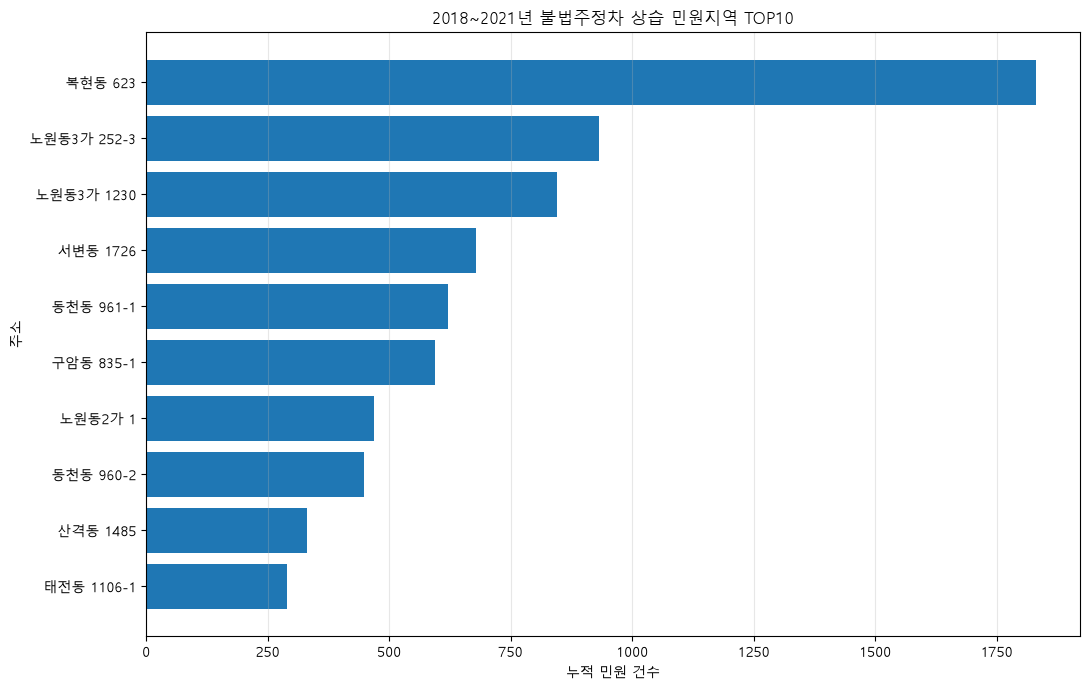

In [6]:
# 상습 민원지역 TOP10을 가로 막대그래프로 나타냅니다.
plt.figure(figsize=(11, 7))
plt.barh(
    hotspot_top10["짧은주소"],
    hotspot_top10["민원발생누적건수"]
)
plt.gca().invert_yaxis()

plt.title("2018~2021년 불법주정차 상습 민원지역 TOP10")
plt.xlabel("누적 민원 건수")
plt.ylabel("주소")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig("../images/hotspot_top10.png", dpi=150, bbox_inches="tight")
plt.show()


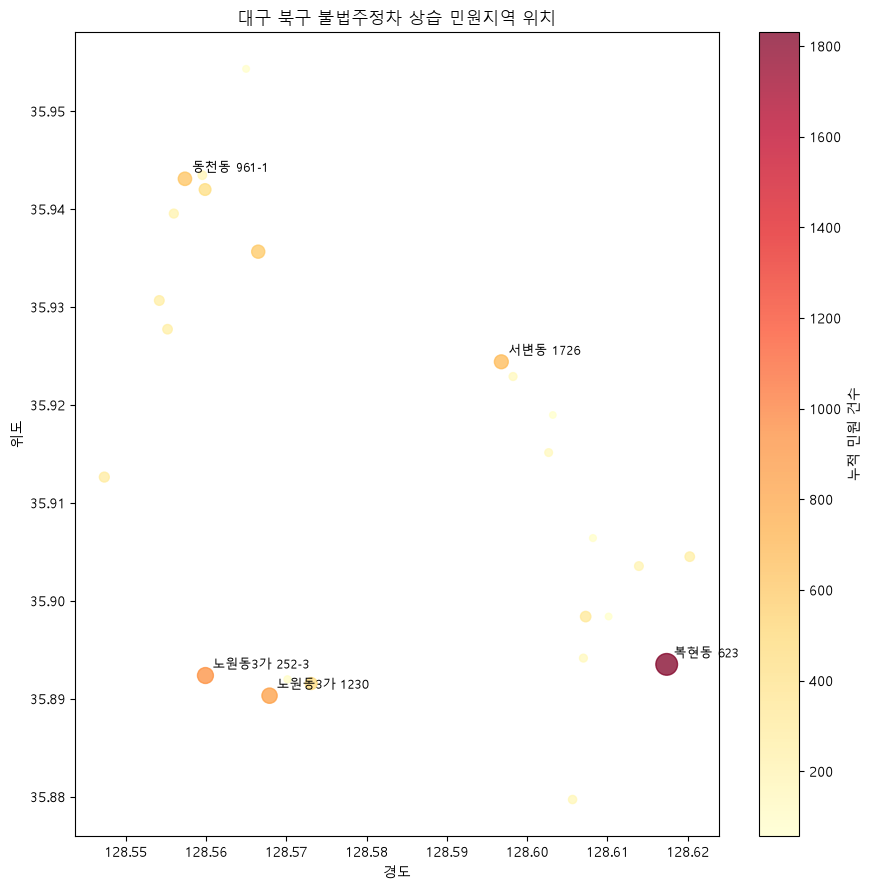

In [7]:
# 상습 발생지 위치를 민원 건수에 따라 점 크기로 나타냅니다.
plt.figure(figsize=(9, 9))

plt.scatter(
    hotspot_clean["경도"],
    hotspot_clean["위도"],
    s=hotspot_clean["민원발생누적건수"] / 8 + 15,
    c=hotspot_clean["민원발생누적건수"],
    cmap="YlOrRd",
    alpha=0.75
)

plt.colorbar(label="누적 민원 건수")

# TOP5는 주소명을 표시합니다.
for _, row in hotspot_top10.head(5).iterrows():
    plt.annotate(
        row["짧은주소"],
        (row["경도"], row["위도"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("대구 북구 불법주정차 상습 민원지역 위치")
plt.xlabel("경도")
plt.ylabel("위도")
plt.tight_layout()

plt.savefig("../images/hotspot_location_map.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# 민원 데이터의 동별 전체 민원 건수를 계산합니다.
complaint_by_dong = (
    complaint[complaint["동"] != "미상"]
    .groupby("동", as_index=False)["민원건수"]
    .sum()
    .rename(columns={"민원건수": "민원건수_2018_2021"})
)

# CCTV 데이터의 동별 CCTV 대수를 계산합니다.
cctv_by_dong = (
    cctv.groupby("동", as_index=False)
    .size()
    .rename(columns={"size": "CCTV수"})
)

# 주정차단속 CCTV만 따로 계산합니다.
parking_cctv_by_dong = (
    cctv[cctv["설치목적구분"] == "주정차단속"]
    .groupby("동", as_index=False)
    .size()
    .rename(columns={"size": "주정차단속CCTV수"})
)

# 상습 발생지의 동별 장소 수와 누적 민원 건수를 계산합니다.
hotspot_by_dong = (
    hotspot_clean.groupby("동", as_index=False)
    .agg(
        상습발생지수=("주소", "nunique"),
        상습지역민원누적=("민원발생누적건수", "sum")
    )
)

# 동 목록을 합칩니다.
dong_summary = complaint_by_dong.merge(
    cctv_by_dong, on="동", how="outer"
).merge(
    parking_cctv_by_dong, on="동", how="outer"
).merge(
    hotspot_by_dong, on="동", how="outer"
)

# 데이터가 없는 값은 0으로 채웁니다.
count_cols = [
    "민원건수_2018_2021", "CCTV수",
    "주정차단속CCTV수", "상습발생지수", "상습지역민원누적"
]

dong_summary[count_cols] = dong_summary[count_cols].fillna(0)

# 정수형으로 변환합니다.
for col in count_cols:
    dong_summary[col] = dong_summary[col].astype(int)

# 민원이 많은 순으로 정렬합니다.
dong_summary = dong_summary.sort_values(
    "민원건수_2018_2021",
    ascending=False
).reset_index(drop=True)

display(dong_summary)


,동,민원건수_2018_2021,CCTV수,주정차단속CCTV수,상습발생지수,상습지역민원누적
0,산격동,10961,80,12,5,793
1,동천동,8869,44,6,3,1249
2,복현동,7303,52,4,2,2084
3,구암동,6635,63,5,3,1114
4,태전동,6098,78,9,1,289
5,침산동,5297,51,6,0,0
6,노원동,4951,23,5,4,2333
7,관음동,4924,34,2,0,0
8,읍내동,4217,61,3,1,211
9,칠성동,3847,45,12,0,0


In [9]:
# 민원 데이터의 동별 전체 민원 건수를 계산합니다.
complaint_by_dong = (
    complaint[complaint["동"] != "미상"]
    .groupby("동", as_index=False)["민원건수"]
    .sum()
    .rename(columns={"민원건수": "민원건수_2018_2021"})
)

# CCTV 데이터의 동별 CCTV 대수를 계산합니다.
cctv_by_dong = (
    cctv.groupby("동", as_index=False)
    .size()
    .rename(columns={"size": "CCTV수"})
)

# 주정차단속 CCTV만 따로 계산합니다.
parking_cctv_by_dong = (
    cctv[cctv["설치목적구분"] == "주정차단속"]
    .groupby("동", as_index=False)
    .size()
    .rename(columns={"size": "주정차단속CCTV수"})
)

# 상습 발생지의 동별 장소 수와 누적 민원 건수를 계산합니다.
hotspot_by_dong = (
    hotspot_clean.groupby("동", as_index=False)
    .agg(
        상습발생지수=("주소", "nunique"),
        상습지역민원누적=("민원발생누적건수", "sum")
    )
)

# 동 목록을 합칩니다.
dong_summary = complaint_by_dong.merge(
    cctv_by_dong, on="동", how="outer"
).merge(
    parking_cctv_by_dong, on="동", how="outer"
).merge(
    hotspot_by_dong, on="동", how="outer"
)

# 데이터가 없는 값은 0으로 채웁니다.
count_cols = [
    "민원건수_2018_2021", "CCTV수",
    "주정차단속CCTV수", "상습발생지수", "상습지역민원누적"
]

dong_summary[count_cols] = dong_summary[count_cols].fillna(0)

# 정수형으로 변환합니다.
for col in count_cols:
    dong_summary[col] = dong_summary[col].astype(int)

# 민원이 많은 순으로 정렬합니다.
dong_summary = dong_summary.sort_values(
    "민원건수_2018_2021",
    ascending=False
).reset_index(drop=True)

display(dong_summary)


,동,민원건수_2018_2021,CCTV수,주정차단속CCTV수,상습발생지수,상습지역민원누적
0,산격동,10961,80,12,5,793
1,동천동,8869,44,6,3,1249
2,복현동,7303,52,4,2,2084
3,구암동,6635,63,5,3,1114
4,태전동,6098,78,9,1,289
5,침산동,5297,51,6,0,0
6,노원동,4951,23,5,4,2333
7,관음동,4924,34,2,0,0
8,읍내동,4217,61,3,1,211
9,칠성동,3847,45,12,0,0


In [10]:
# 민원이 많은 상위 10개 동을 선택합니다.
top_dong = dong_summary.head(10).copy()

# 민원 건수와 주정차단속 CCTV 수를 각각 확인합니다.
display(
    top_dong[
        ["동", "민원건수_2018_2021", "주정차단속CCTV수", "상습발생지수"]
    ]
)


,동,민원건수_2018_2021,주정차단속CCTV수,상습발생지수
0,산격동,10961,12,5
1,동천동,8869,6,3
2,복현동,7303,4,2
3,구암동,6635,5,3
4,태전동,6098,9,1
5,침산동,5297,6,0
6,노원동,4951,5,4
7,관음동,4924,2,0
8,읍내동,4217,3,1
9,칠성동,3847,12,0


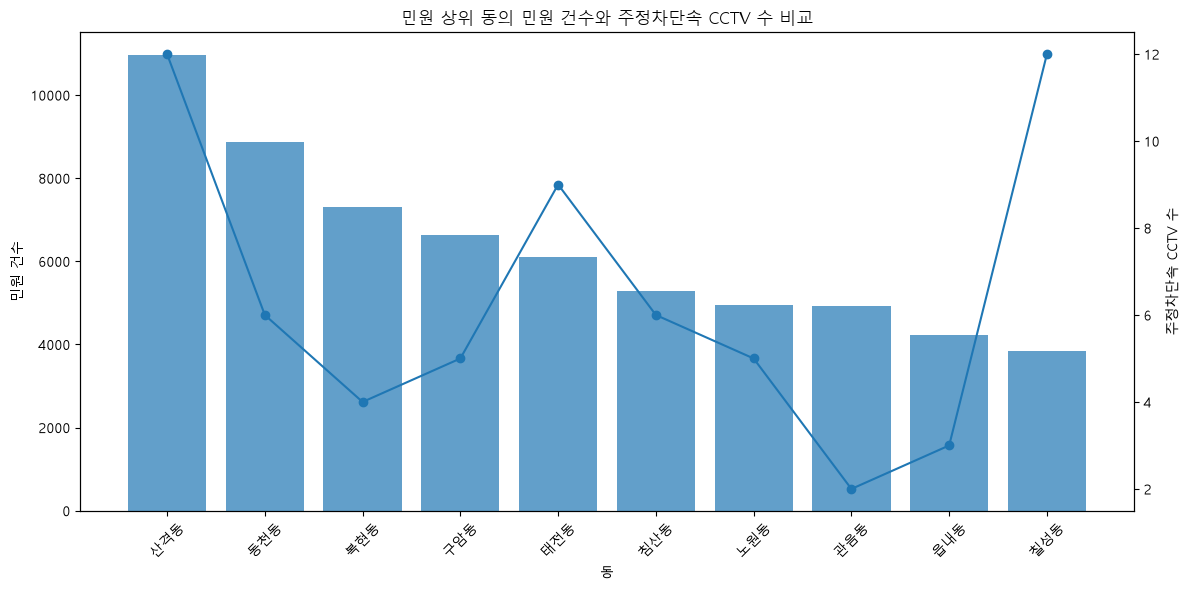

In [11]:
# 민원 건수가 많은 동의 CCTV 설치 대수를 함께 비교합니다.
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    top_dong["동"],
    top_dong["민원건수_2018_2021"],
    alpha=0.7
)
ax1.set_xlabel("동")
ax1.set_ylabel("민원 건수")
ax1.tick_params(axis="x", rotation=45)

# 오른쪽 축에는 주정차단속 CCTV 수를 표시합니다.
ax2 = ax1.twinx()
ax2.plot(
    top_dong["동"],
    top_dong["주정차단속CCTV수"],
    marker="o"
)
ax2.set_ylabel("주정차단속 CCTV 수")

plt.title("민원 상위 동의 민원 건수와 주정차단속 CCTV 수 비교")
fig.tight_layout()

plt.savefig("../images/hotspot_dong_complaint_cctv.png", dpi=150, bbox_inches="tight")
plt.show()



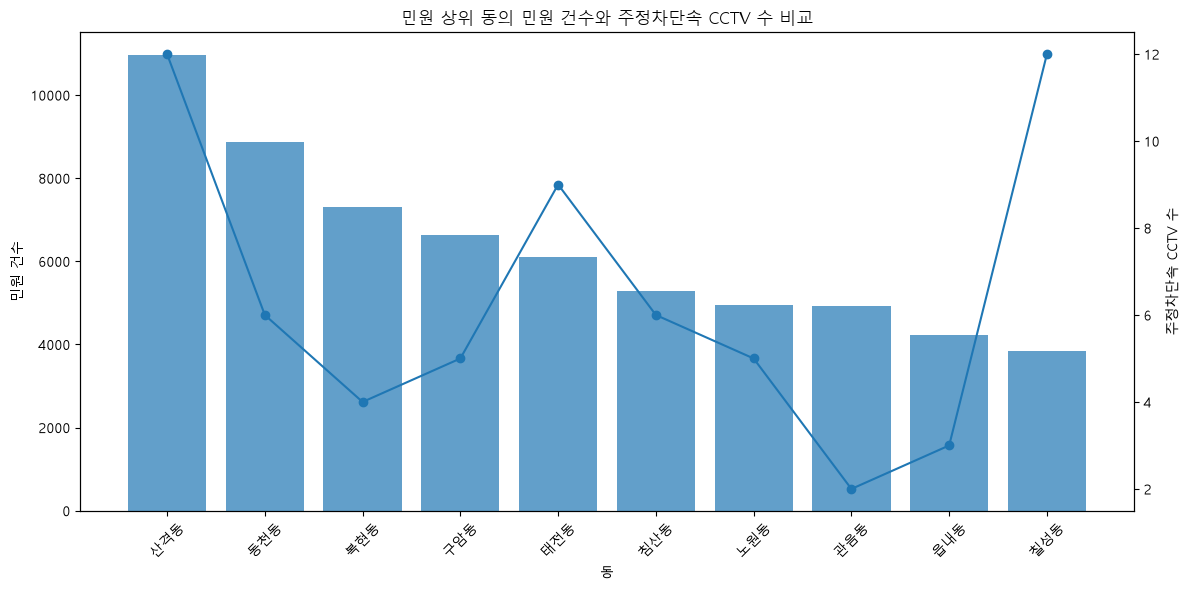

In [12]:
# 민원 건수가 많은 동의 CCTV 설치 대수를 함께 비교합니다.
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    top_dong["동"],
    top_dong["민원건수_2018_2021"],
    alpha=0.7
)
ax1.set_xlabel("동")
ax1.set_ylabel("민원 건수")
ax1.tick_params(axis="x", rotation=45)

# 오른쪽 축에는 주정차단속 CCTV 수를 표시합니다.
ax2 = ax1.twinx()
ax2.plot(
    top_dong["동"],
    top_dong["주정차단속CCTV수"],
    marker="o"
)
ax2.set_ylabel("주정차단속 CCTV 수")

plt.title("민원 상위 동의 민원 건수와 주정차단속 CCTV 수 비교")
fig.tight_layout()

plt.savefig("../images/hotspot_dong_complaint_cctv.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# 단속구분별 건수를 계산합니다.
enforcement_type = (
    violation_2025["단속구분"]
    .value_counts()
)

# 비율도 계산합니다.
enforcement_ratio = (
    enforcement_type / enforcement_type.sum() * 100
).round(1)

enforcement_summary = pd.DataFrame({
    "단속건수": enforcement_type,
    "비율(%)": enforcement_ratio
})

display(enforcement_summary)



,단속건수,비율(%)
단속구분,,
안전신문고,4679,38.2
고정형CCTV,4529,37.0
주행형CCTV,3003,24.5
버스장착형CCTV,30,0.2


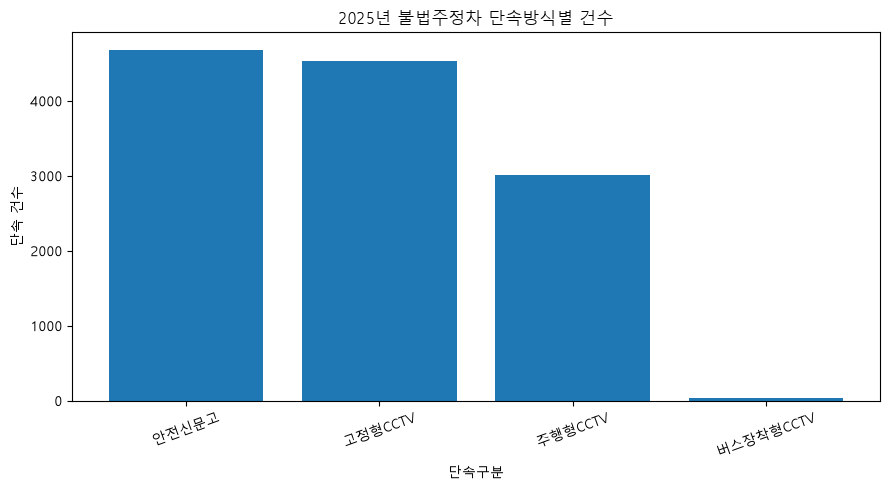

In [14]:
# 단속방식별 건수를 막대그래프로 나타냅니다.
plt.figure(figsize=(9, 5))
plt.bar(
    enforcement_type.index,
    enforcement_type.values
)

plt.title("2025년 불법주정차 단속방식별 건수")
plt.xlabel("단속구분")
plt.ylabel("단속 건수")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../images/hotspot_2025_enforcement_type.png", dpi=150, bbox_inches="tight")
plt.show()



In [15]:
# 상습 발생지 정리 데이터 저장
hotspot_path = "../data/processed/hotspot_clean.csv"
hotspot_clean.to_csv(
    hotspot_path,
    index=False,
    encoding="utf-8-sig"
)

# 동별 민원/CCTV/상습 발생지 통합 데이터 저장
dong_path = "../data/processed/dong_support_summary.csv"
dong_summary.to_csv(
    dong_path,
    index=False,
    encoding="utf-8-sig"
)

# 2025 단속방식 요약 저장
enforcement_path = "../data/processed/enforcement_2025_summary.csv"
enforcement_summary.reset_index().rename(
    columns={"단속구분": "단속구분", "index": "단속구분"}
).to_csv(
    enforcement_path,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", hotspot_path)
print("저장 완료:", dong_path)
print("저장 완료:", enforcement_path)


저장 완료: ../data/processed/hotspot_clean.csv
저장 완료: ../data/processed/dong_support_summary.csv
저장 완료: ../data/processed/enforcement_2025_summary.csv


In [16]:
# 핵심 결과를 출력합니다.
top_hotspot = hotspot_top10.iloc[0]
top_complaint_dong = dong_summary.iloc[0]

print("상습 민원 최다 지역:", top_hotspot["짧은주소"])
print("누적 민원 건수:", f"{int(top_hotspot['민원발생누적건수']):,}", "건")
print()

print("민원 건수가 가장 많은 동:", top_complaint_dong["동"])
print("민원 건수:", f"{int(top_complaint_dong['민원건수_2018_2021']):,}", "건")
print("주정차단속 CCTV 수:", int(top_complaint_dong["주정차단속CCTV수"]), "대")
print("상습 발생지 수:", int(top_complaint_dong["상습발생지수"]), "곳")
print()

print("※ 2025 단속방식 데이터는 장소 정보가 없어 지역별 관리등급 계산에는 직접 사용하지 않습니다.")
print("※ 민원, CCTV, 상습 발생지 결과는 06_final_analysis에서 단속 데이터와 함께 종합합니다.")


상습 민원 최다 지역: 복현동 623
누적 민원 건수: 1,830 건

민원 건수가 가장 많은 동: 산격동
민원 건수: 10,961 건
주정차단속 CCTV 수: 12 대
상습 발생지 수: 5 곳

※ 2025 단속방식 데이터는 장소 정보가 없어 지역별 관리등급 계산에는 직접 사용하지 않습니다.
※ 민원, CCTV, 상습 발생지 결과는 06_final_analysis에서 단속 데이터와 함께 종합합니다.
